# Цель задачи

**Разработать модель машинного обучения, которая на основе химических тестов сможет предсказывать, является ли вино настоящим или поддельным, то есть определять разницу между дешёвыми и дорогими винами.**

Чаще всего вино подделывают, разбавляя его более дешёвыми продуктами (например, соком), а иногда и с помощью опасных химикатов или подсластителей (чтобы добавить цвет или вкус).

Другой тип подделки - продажа более дешёвых вин под более дорогими марками.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("wine_fraud.csv")

In [3]:
df = df[df.duplicated() == False]
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,Legit,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,Legit,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,Legit,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,Legit,red
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,Legit,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,Legit,white
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,Legit,white
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,Legit,white
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,Legit,white


In [4]:
np.round((df['type'].value_counts()) / len(df),2)

white    0.74
red      0.26
Name: type, dtype: float64

In [5]:
np.round((df['quality'].value_counts()) / len(df),2)

Legit    0.96
Fraud    0.04
Name: quality, dtype: float64

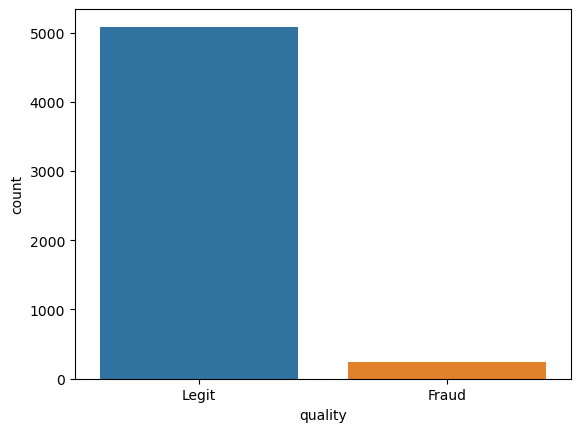

In [6]:
sns.countplot(data=df,x='quality');

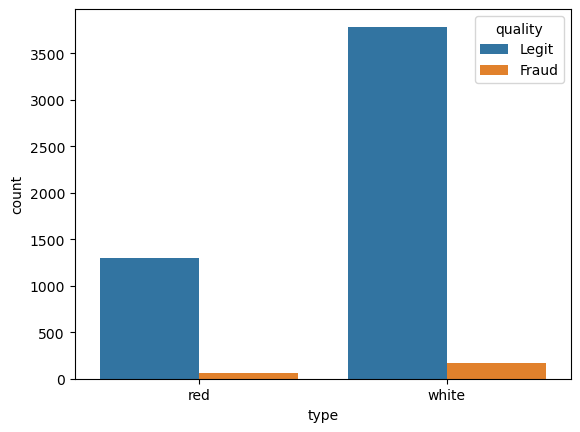

In [7]:
sns.countplot(data=df,x='type',hue='quality');

**Какой процент красных вин является подделкой? Какой процент белых вин является подделкой?**

In [8]:
df.groupby(['type','quality']).count()['pH']

type   quality
red    Fraud        63
       Legit      1296
white  Fraud       173
       Legit      3788
Name: pH, dtype: int64

In [9]:
print(f'Поддельных белых вин: {np.round(len(df[(df["type"] == "white") & (df["quality"] == "Fraud")]) / len(df[df["type"] == "white"]), 2) * 100}%')

Поддельных белых вин: 4.0%


In [10]:
print(f'Поддельных красных вин: {np.round(len(df[(df["type"] == "red") & (df["quality"] == "Fraud")]) / len(df[df["type"] == "red"]), 2) * 100}%')

Поддельных красных вин: 5.0%


**Вычислю корреляцию между различными признаками и колонкой "quality"**

In [11]:
df['quality']= df['quality'].map({'Legit':0,'Fraud':1})

In [12]:
df.corr()['quality']

fixed acidity           0.025957
volatile acidity        0.160332
citric acid            -0.067037
residual sugar         -0.041803
chlorides               0.034605
free sulfur dioxide    -0.088387
total sulfur dioxide   -0.037892
density                 0.028054
pH                      0.018783
sulphates              -0.037451
alcohol                -0.060721
quality                 1.000000
Name: quality, dtype: float64

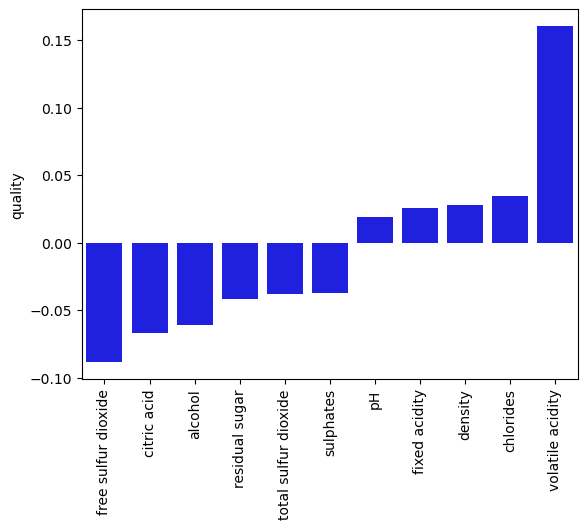

In [13]:
sns.barplot(x=df.corr()['quality'].sort_values()[:-1].index, y=df.corr()['quality'].sort_values()[:-1],color='blue')
plt.xticks(rotation=90);

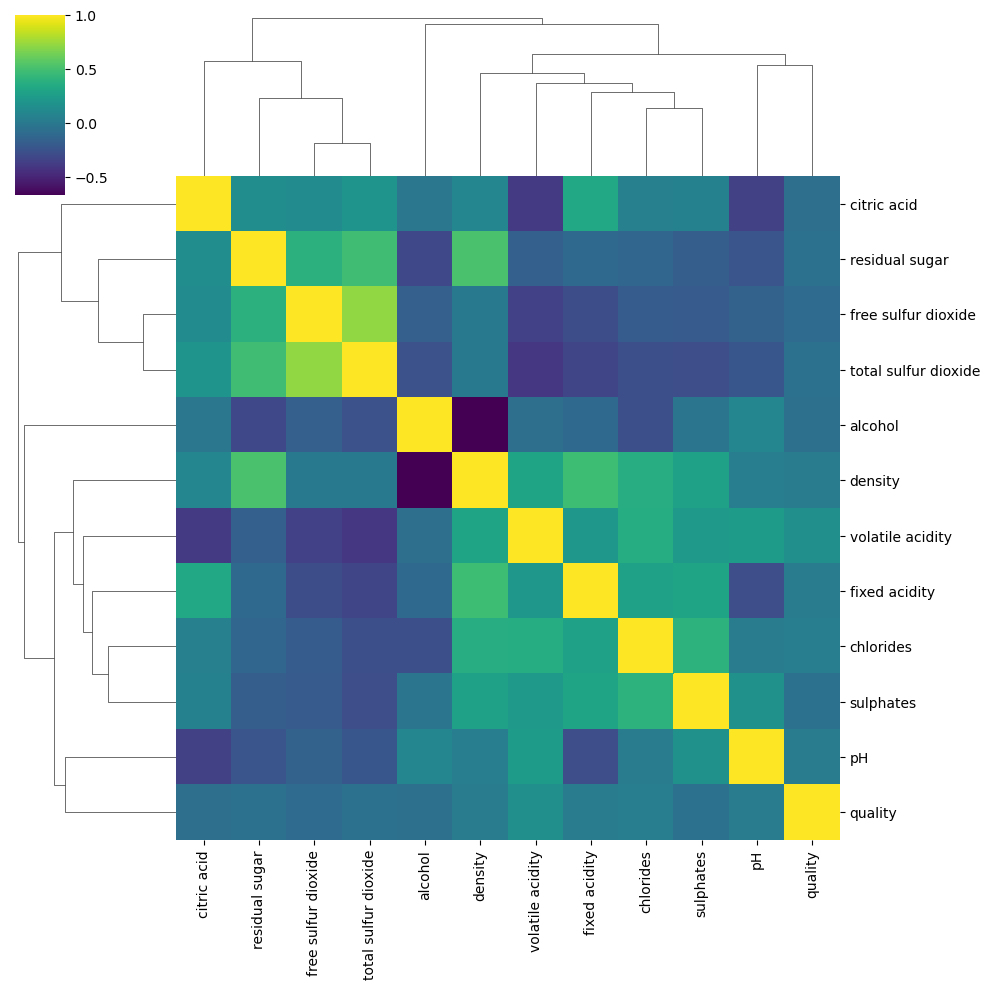

In [14]:
sns.clustermap(df.corr(),cmap='viridis');

## Модель машинного обучения

In [15]:
# Напишите Ваш код здесь
df['type'] = pd.get_dummies(df['type'],drop_first=True)

In [16]:
X = df.drop('quality',axis=1)
y = df['quality']

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.1,random_state=101)

In [19]:
from sklearn.preprocessing import StandardScaler

In [20]:
scaler = StandardScaler()

In [21]:
scaled_x_train = scaler.fit_transform(X_train)
scaled_x_test = scaler.transform(X_test)

In [22]:
from sklearn.svm import SVC

In [23]:
svc = SVC(class_weight='balanced')

In [24]:
param_grid = {'C':[0.001,0.01,0.1,0.5,1,5,10,50,100,500,1000],
             'kernel':['linear','rbf','poly'],
             'gamma':['scale','auto'],
             'degree':[2,3,4]}

In [25]:
from sklearn.model_selection import GridSearchCV

In [26]:
grid = GridSearchCV(svc,param_grid,n_jobs=-1,verbose=50)

In [27]:
grid.fit(scaled_x_train,y_train)

Fitting 5 folds for each of 198 candidates, totalling 990 fits
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done   3 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done  11 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed: 

[Parallel(n_jobs=-1)]: Done 140 tasks      | elapsed:   11.6s
[Parallel(n_jobs=-1)]: Done 141 tasks      | elapsed:   12.2s
[Parallel(n_jobs=-1)]: Done 142 tasks      | elapsed:   12.4s
[Parallel(n_jobs=-1)]: Done 143 tasks      | elapsed:   12.4s
[Parallel(n_jobs=-1)]: Done 144 tasks      | elapsed:   12.4s
[Parallel(n_jobs=-1)]: Done 145 tasks      | elapsed:   12.4s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:   12.5s
[Parallel(n_jobs=-1)]: Done 147 tasks      | elapsed:   12.5s
[Parallel(n_jobs=-1)]: Done 148 tasks      | elapsed:   12.5s
[Parallel(n_jobs=-1)]: Done 149 tasks      | elapsed:   12.5s
[Parallel(n_jobs=-1)]: Done 150 tasks      | elapsed:   12.6s
[Parallel(n_jobs=-1)]: Done 151 tasks      | elapsed:   12.6s
[Parallel(n_jobs=-1)]: Done 152 tasks      | elapsed:   12.6s
[Parallel(n_jobs=-1)]: Done 153 tasks      | elapsed:   12.6s
[Parallel(n_jobs=-1)]: Done 154 tasks      | elapsed:   12.6s
[Parallel(n_jobs=-1)]: Done 155 tasks      | elapsed:   12.7s
[Paralle

[Parallel(n_jobs=-1)]: Done 274 tasks      | elapsed:   18.9s
[Parallel(n_jobs=-1)]: Done 275 tasks      | elapsed:   19.0s
[Parallel(n_jobs=-1)]: Done 276 tasks      | elapsed:   19.0s
[Parallel(n_jobs=-1)]: Done 277 tasks      | elapsed:   19.1s
[Parallel(n_jobs=-1)]: Done 278 tasks      | elapsed:   19.1s
[Parallel(n_jobs=-1)]: Done 279 tasks      | elapsed:   19.1s
[Parallel(n_jobs=-1)]: Done 280 tasks      | elapsed:   19.2s
[Parallel(n_jobs=-1)]: Done 281 tasks      | elapsed:   19.2s
[Parallel(n_jobs=-1)]: Done 282 tasks      | elapsed:   19.3s
[Parallel(n_jobs=-1)]: Done 283 tasks      | elapsed:   19.5s
[Parallel(n_jobs=-1)]: Done 284 tasks      | elapsed:   19.5s
[Parallel(n_jobs=-1)]: Done 285 tasks      | elapsed:   19.5s
[Parallel(n_jobs=-1)]: Done 286 tasks      | elapsed:   19.7s
[Parallel(n_jobs=-1)]: Done 287 tasks      | elapsed:   19.8s
[Parallel(n_jobs=-1)]: Done 288 tasks      | elapsed:   19.8s
[Parallel(n_jobs=-1)]: Done 289 tasks      | elapsed:   19.8s
[Paralle

[Parallel(n_jobs=-1)]: Done 410 tasks      | elapsed:   26.8s
[Parallel(n_jobs=-1)]: Done 411 tasks      | elapsed:   26.8s
[Parallel(n_jobs=-1)]: Done 412 tasks      | elapsed:   27.2s
[Parallel(n_jobs=-1)]: Done 413 tasks      | elapsed:   27.2s
[Parallel(n_jobs=-1)]: Done 414 tasks      | elapsed:   27.3s
[Parallel(n_jobs=-1)]: Done 415 tasks      | elapsed:   27.3s
[Parallel(n_jobs=-1)]: Done 416 tasks      | elapsed:   27.3s
[Parallel(n_jobs=-1)]: Done 417 tasks      | elapsed:   27.3s
[Parallel(n_jobs=-1)]: Done 418 tasks      | elapsed:   27.4s
[Parallel(n_jobs=-1)]: Done 419 tasks      | elapsed:   27.5s
[Parallel(n_jobs=-1)]: Done 420 tasks      | elapsed:   27.5s
[Parallel(n_jobs=-1)]: Done 421 tasks      | elapsed:   27.6s
[Parallel(n_jobs=-1)]: Done 422 tasks      | elapsed:   27.6s
[Parallel(n_jobs=-1)]: Done 423 tasks      | elapsed:   27.8s
[Parallel(n_jobs=-1)]: Done 424 tasks      | elapsed:   27.8s
[Parallel(n_jobs=-1)]: Done 425 tasks      | elapsed:   27.8s
[Paralle

[Parallel(n_jobs=-1)]: Done 543 tasks      | elapsed:   40.3s
[Parallel(n_jobs=-1)]: Done 544 tasks      | elapsed:   40.5s
[Parallel(n_jobs=-1)]: Done 545 tasks      | elapsed:   40.7s
[Parallel(n_jobs=-1)]: Done 546 tasks      | elapsed:   40.8s
[Parallel(n_jobs=-1)]: Done 547 tasks      | elapsed:   40.8s
[Parallel(n_jobs=-1)]: Done 548 tasks      | elapsed:   40.8s
[Parallel(n_jobs=-1)]: Done 549 tasks      | elapsed:   41.0s
[Parallel(n_jobs=-1)]: Done 550 tasks      | elapsed:   41.0s
[Parallel(n_jobs=-1)]: Done 551 tasks      | elapsed:   41.2s
[Parallel(n_jobs=-1)]: Done 552 tasks      | elapsed:   41.3s
[Parallel(n_jobs=-1)]: Done 553 tasks      | elapsed:   41.3s
[Parallel(n_jobs=-1)]: Done 554 tasks      | elapsed:   41.3s
[Parallel(n_jobs=-1)]: Done 555 tasks      | elapsed:   41.5s
[Parallel(n_jobs=-1)]: Done 556 tasks      | elapsed:   42.6s
[Parallel(n_jobs=-1)]: Done 557 tasks      | elapsed:   42.6s
[Parallel(n_jobs=-1)]: Done 558 tasks      | elapsed:   42.8s
[Paralle

[Parallel(n_jobs=-1)]: Done 676 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 677 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 678 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 679 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 680 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 681 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 682 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 683 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 684 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 685 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 686 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 687 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 688 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 689 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 690 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 691 tasks      | elapsed:  1.2min
[Paralle

[Parallel(n_jobs=-1)]: Done 809 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done 810 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done 811 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done 812 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done 813 tasks      | elapsed:  2.4min
[Parallel(n_jobs=-1)]: Done 814 tasks      | elapsed:  2.4min
[Parallel(n_jobs=-1)]: Done 815 tasks      | elapsed:  2.4min
[Parallel(n_jobs=-1)]: Done 816 tasks      | elapsed:  2.4min
[Parallel(n_jobs=-1)]: Done 817 tasks      | elapsed:  2.4min
[Parallel(n_jobs=-1)]: Done 818 tasks      | elapsed:  2.4min
[Parallel(n_jobs=-1)]: Done 819 tasks      | elapsed:  2.4min
[Parallel(n_jobs=-1)]: Done 820 tasks      | elapsed:  2.5min
[Parallel(n_jobs=-1)]: Done 821 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-1)]: Done 822 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-1)]: Done 823 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-1)]: Done 824 tasks      | elapsed:  2.6min
[Paralle

[Parallel(n_jobs=-1)]: Done 942 tasks      | elapsed:  9.1min
[Parallel(n_jobs=-1)]: Done 943 tasks      | elapsed:  9.1min
[Parallel(n_jobs=-1)]: Done 944 tasks      | elapsed:  9.1min
[Parallel(n_jobs=-1)]: Done 945 tasks      | elapsed:  9.2min
[Parallel(n_jobs=-1)]: Done 946 tasks      | elapsed:  9.5min
[Parallel(n_jobs=-1)]: Done 947 tasks      | elapsed:  9.6min
[Parallel(n_jobs=-1)]: Done 948 tasks      | elapsed:  9.6min
[Parallel(n_jobs=-1)]: Done 949 tasks      | elapsed:  9.7min
[Parallel(n_jobs=-1)]: Done 950 tasks      | elapsed:  9.7min
[Parallel(n_jobs=-1)]: Done 951 tasks      | elapsed:  9.7min
[Parallel(n_jobs=-1)]: Done 952 tasks      | elapsed:  9.7min
[Parallel(n_jobs=-1)]: Done 953 tasks      | elapsed:  9.8min
[Parallel(n_jobs=-1)]: Done 954 tasks      | elapsed:  9.8min
[Parallel(n_jobs=-1)]: Done 955 tasks      | elapsed:  9.8min
[Parallel(n_jobs=-1)]: Done 956 tasks      | elapsed:  9.8min
[Parallel(n_jobs=-1)]: Done 957 tasks      | elapsed:  9.8min
[Paralle

GridSearchCV(estimator=SVC(class_weight='balanced'), n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100, 500,
                               1000],
                         'degree': [2, 3, 4], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf', 'poly']},
             verbose=50)

In [28]:
grid.best_params_

{'C': 0.001, 'degree': 4, 'gamma': 'scale', 'kernel': 'poly'}

**Посмотрю результаты**

In [29]:
from sklearn.metrics import confusion_matrix, plot_confusion_matrix, classification_report

In [30]:
print(classification_report(y_test,grid.predict(scaled_x_test)))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       513
           1       0.38      0.26      0.31        19

    accuracy                           0.96       532
   macro avg       0.68      0.62      0.65       532
weighted avg       0.95      0.96      0.95       532



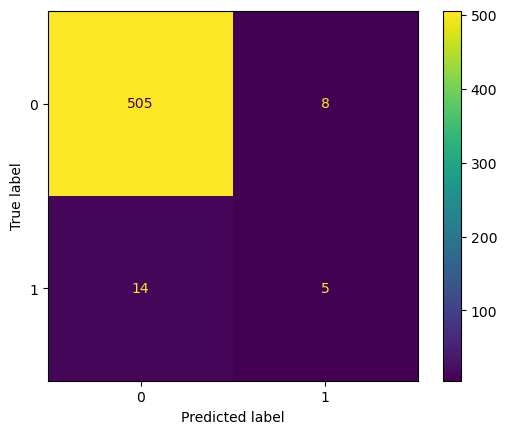

In [31]:
plot_confusion_matrix(grid,scaled_x_test,y_test);

In [32]:
from sklearn.metrics import plot_precision_recall_curve, plot_roc_curve

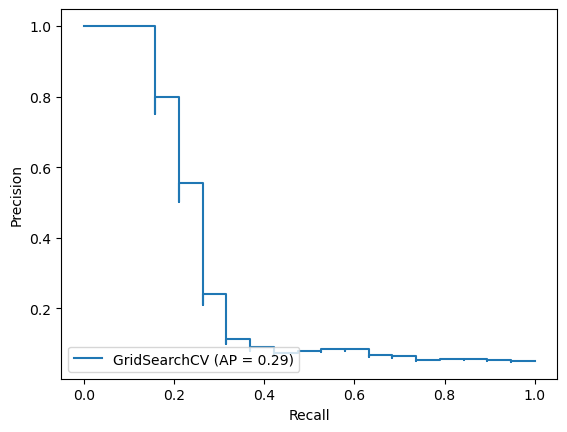

In [33]:
plot_precision_recall_curve(grid,scaled_x_test,y_test);

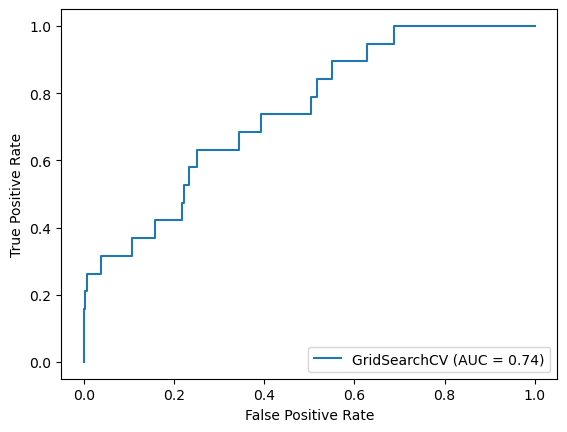

In [34]:
plot_roc_curve(grid,scaled_x_test,y_test);

**Модель работает плохо и не пригодна к применению.** Несмотря на высокую общую точность, этот показатель обманчив из-за сильного дисбаланса классов (всего 4% подделок). Ключевые метрики для выявления мошенничества критически низки: точность составляет 38%, а полнота — всего 26%. Это означает, что модель пропускает 74% реальных подделок и ошибочно обвиняет 62% хороших вин. F1-score на уровне 31% подтверждает, что модель не справляется с главной задачей.

**В реальной жизни такая модель работать не будет и даже опасна.** Пропуск поддельных вин может привести к серьезным последствиям для здоровья потребителей и репутации бренда. Дисбаланс классов, скорее всего, будет ещё более выраженным в реальных условиях, а способы подделки постоянно меняются, что сделает модель бесполезной со временем. Для промышленного применения требовались бы методы борьбы с дисбалансом, сбор большего количества данных о подделках и оценка качества по F1-score, а не по accuracy.

**Но даже с параметром class_weight='balanced' результат остаётся неудовлетворительным.** Проблема не только в настройках SVM — этот параметр лишь немного помог. Корень проблемы в самой структуре данных: признаки поддельных и настоящих вин слишком сильно перекрываются, и даже с весами SVM не может надёжно разделить классы. Здесь нужны более сложные методы или глубокая работа с признаками — их отбор, трансформация или создание новых.